In [47]:
# Basic usage sketch
from kan import KAN
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
# import scaler
from sklearn.preprocessing import StandardScaler
import sympy

# Example: synthetic regression data
X = torch.empty(2000, 1).uniform_(-10, 100)
Z = torch.empty(2000, 1).uniform_(-10, 100)
#y = (X ** 3) + 0.01 * torch.randn_like(X) + (Z ** 2) + 0.01 * torch.randn_like(Z)
y = X - Z

scaler = StandardScaler()
y = scaler.fit_transform(y.numpy())
y = torch.tensor(y, dtype=torch.float32)

# Standardize both inputs and outputs
#X = (X - X.mean()) / X.std()
#Z = (Z - Z.mean()) / Z.std()


# Set up dataset
X = torch.cat([X, Z], dim=1)  # concatenate X and Z
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

## Tutorial for KAN model
input_size = X.shape[1]
output_size = y.shape[1]

# Instantiate a simple KAN model
params = {
        'width': [2, 1],
        'grid':5, 
        'k':4, 
}

model = KAN(**params)

# update grid
model.update_grid_from_samples(X)

# Choose optimizer & loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Training loop
for epoch in range(100):
    for xb, yb in loader:

        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch}: loss = {loss.item():.4f}')


checkpoint directory created: ./model
saving model version 0.0
Epoch 0: loss = 68.0782
Epoch 50: loss = 0.0029


In [48]:
# print mean and variance of the scaler
print("Scaler mean:", scaler.mean_)
print("Scaler var:", scaler.var_)

Scaler mean: [1.88209052]
Scaler var: [2065.99131246]


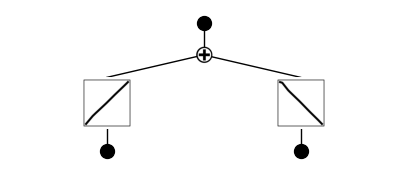

In [49]:
model.plot()

In [50]:
# Prune model
model.prune()

saving model version 0.1


MultKAN(
  (act_fun): ModuleList(
    (0): KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
  (symbolic_fun): ModuleList(
    (0): Symbolic_KANLayer()
  )
)

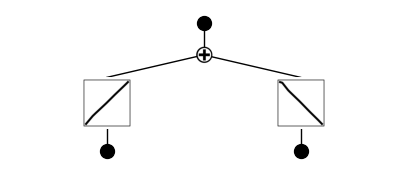

In [51]:
model.plot()

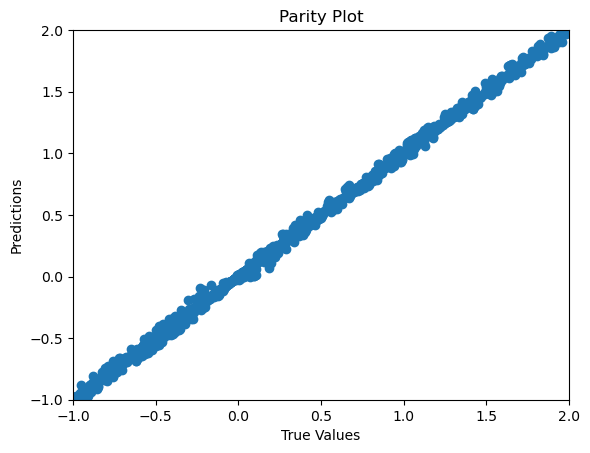

In [52]:
from matplotlib import pyplot as plt

# Collect all batches into single tensors
all_xb = []
all_yb = []
preds = []
for xb, yb in loader:
    all_xb.append(xb)
    all_yb.append(yb)
    preds.append(model(xb))
all_xb = torch.cat(all_xb, dim=0)
all_yb = torch.cat(all_yb, dim=0)
preds = torch.cat(preds, dim=0)

# parity plot between yb and the model's predictions
plt.scatter(all_yb.detach().numpy(), preds.detach().numpy())
plt.xlim([-1, 2])
plt.ylim([-1, 2])
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("Parity Plot")
plt.show()

In [53]:
# clone model
symbolic_model = model

#lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
#lib = ['x', 'x^2', 'x^3']
symbolic_model.auto_symbolic()

# Show discovered symbolic formulas
print("\nDiscovered symbolic formula(s):")
expr = symbolic_model.symbolic_formula()[0]  
print(expr)

fixing (0,0,0) with x, r2=0.9998283386230469, c=1
fixing (0,1,0) with x, r2=0.9994633197784424, c=1
saving model version 0.1

Discovered symbolic formula(s):
[0.0222892919517683*x_1 - 0.0222232181647768*x_2 - 0.0390018655389941]


In [54]:
(expr[0]*(scaler.var_**0.5) + scaler.mean_)

array([1.01311913549252*x_1 - 1.01011587194784*x_2 + 0.109331817637687],
      dtype=object)

In [55]:
denormalized = sympy.simplify(expr[0]*(scaler.var_**0.5) + scaler.mean_)

In [58]:
str(denormalized[0])

'1.01311913549252*x_1 - 1.01011587194784*x_2 + 0.109331817637687'

In [ ]:
# Define new symbols
u, v = sympy.symbols('c0 c1')

# Replace x -> u and y -> v
expr_new = expr.subs({x: u, y: v})